In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
data = {
    'Student_ID':[101,102,103,104,105,106,107,108,109,110],
    'Attendance':[95,80,60,88,70,55,92,65,85,50],
    'Assignment':[90,75,50,85,60,45,95,55,80,40],
    'Participation':[9,7,4,8,6,3,10,5,7,2],
    'Exam':[92,78,55,88,65,48,96,60,82,45]
}
df = pd.DataFrame(data)
df.head()

,Student_ID,Attendance,Assignment,Participation,Exam
0,101,95,90,9,92
1,102,80,75,7,78
2,103,60,50,4,55
3,104,88,85,8,88
4,105,70,60,6,65


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Student_ID     10 non-null     int64
 1   Attendance     10 non-null     int64
 2   Assignment     10 non-null     int64
 3   Participation  10 non-null     int64
 4   Exam           10 non-null     int64
dtypes: int64(5)
memory usage: 532.0 bytes


In [4]:
df.describe()

,Student_ID,Attendance,Assignment,Participation,Exam
count,10.00000,10.000000,10.000000,10.000000,10.000000
mean,105.50000,74.000000,67.500000,6.100000,70.900000
std,3.02765,16.152055,19.895561,2.601282,18.687191
min,101.00000,50.000000,40.000000,2.000000,45.000000
25%,103.25000,61.250000,51.250000,4.250000,56.250000
50%,105.50000,75.000000,67.500000,6.500000,71.500000
75%,107.75000,87.250000,83.750000,7.750000,86.500000
max,110.00000,95.000000,95.000000,10.000000,96.000000


In [5]:
df.isnull().sum()

,0
Student_ID,0
Attendance,0
Assignment,0
Participation,0
Exam,0


In [10]:
df["Average"] = (
    df["Attendance"] +
    df["Assignment"] +
    df["Exam"]
)/3
df.head()

,Student_ID,Attendance,Assignment,Participation,Exam,Average,Performance
0,101,95,90,9,92,92.333333,Excellent
1,102,80,75,7,78,77.666667,Good
2,103,60,50,4,55,55.000000,Average
3,104,88,85,8,88,87.000000,Excellent
4,105,70,60,6,65,65.000000,Average


In [9]:
def performance(avg):
    if avg>=85:
        return "Excellent"
    elif avg>=70:
        return "Good"
    elif avg>=50:
        return "Average"
    else:
        return "Poor"
df["Performance"] = df["Average"].apply(performance)
df

,Student_ID,Attendance,Assignment,Participation,Exam,Average,Performance
0,101,95,90,9,92,92.333333,Excellent
1,102,80,75,7,78,77.666667,Good
2,103,60,50,4,55,55.000000,Average
3,104,88,85,8,88,87.000000,Excellent
4,105,70,60,6,65,65.000000,Average
5,106,55,45,3,48,49.333333,Poor
6,107,92,95,10,96,94.333333,Excellent
7,108,65,55,5,60,60.000000,Average
8,109,85,80,7,82,82.333333,Good
9,110,50,40,2,45,45.000000,Poor


In [11]:
risk = df[
    (df["Attendance"]<60) |
    (df["Exam"]<50)
]

print(risk)

   Student_ID  Attendance  Assignment  Participation  Exam    Average  \
5         106          55          45              3    48  49.333333   
9         110          50          40              2    45  45.000000   

  Performance  
5        Poor  
9        Poor  


In [12]:
print(df["Performance"].value_counts())

Performance
Excellent    3
Average      3
Good         2
Poor         2
Name: count, dtype: int64


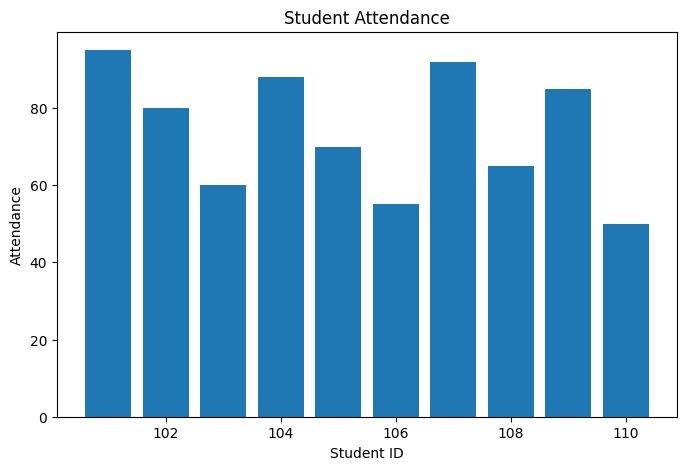

In [13]:
plt.figure(figsize=(8,5))
plt.bar(df["Student_ID"],df["Attendance"])
plt.title("Student Attendance")
plt.xlabel("Student ID")
plt.ylabel("Attendance")
plt.show()

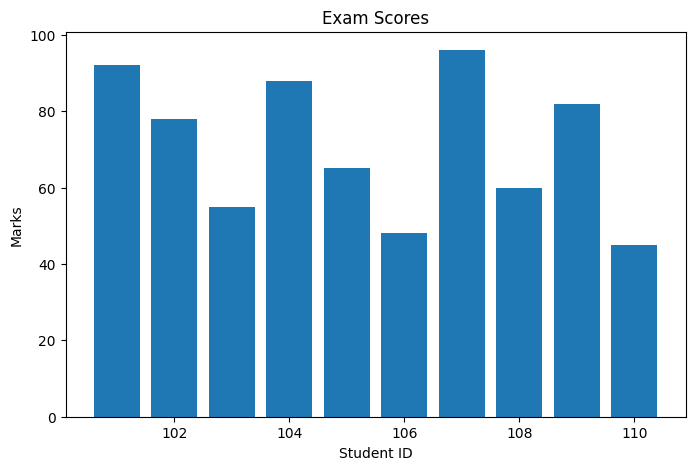

In [14]:
plt.figure(figsize=(8,5))
plt.bar(df["Student_ID"],df["Exam"])
plt.title("Exam Scores")
plt.xlabel("Student ID")
plt.ylabel("Marks")
plt.show()

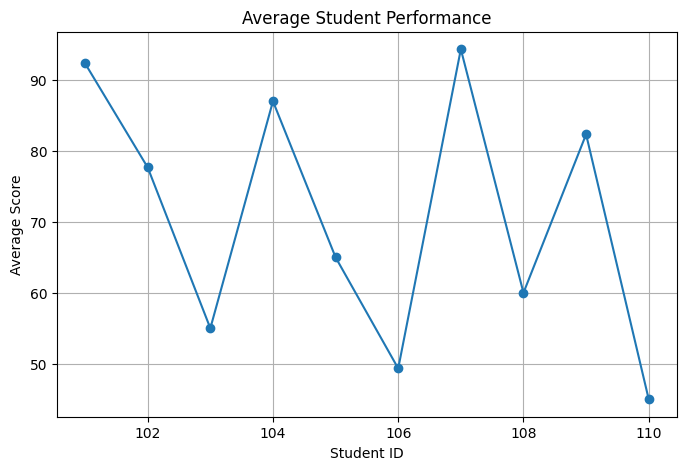

In [15]:
plt.figure(figsize=(8,5))
plt.plot(df["Student_ID"],df["Average"],marker='o')
plt.title("Average Student Performance")
plt.xlabel("Student ID")
plt.ylabel("Average Score")
plt.grid(True)
plt.show()

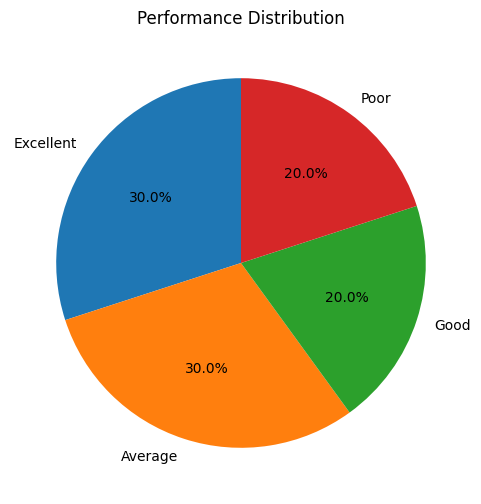

In [16]:
performance_count = df["Performance"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    performance_count,
    labels=performance_count.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Performance Distribution")
plt.show()

In [17]:
print(df[["Attendance","Assignment","Participation","Exam"]].corr())

               Attendance  Assignment  Participation      Exam
Attendance       1.000000    0.992328       0.978462  0.993915
Assignment       0.992328    1.000000       0.982212  0.998915
Participation    0.978462    0.982212       1.000000  0.985381
Exam             0.993915    0.998915       0.985381  1.000000


In [18]:
print(df)

   Student_ID  Attendance  Assignment  Participation  Exam    Average  \
0         101          95          90              9    92  92.333333   
1         102          80          75              7    78  77.666667   
2         103          60          50              4    55  55.000000   
3         104          88          85              8    88  87.000000   
4         105          70          60              6    65  65.000000   
5         106          55          45              3    48  49.333333   
6         107          92          95             10    96  94.333333   
7         108          65          55              5    60  60.000000   
8         109          85          80              7    82  82.333333   
9         110          50          40              2    45  45.000000   

  Performance  
0   Excellent  
1        Good  
2     Average  
3   Excellent  
4     Average  
5        Poor  
6   Excellent  
7     Average  
8        Good  
9        Poor  
